In [1]:
#All needed imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Added machine learning & mining tools in the first block for reproduability purposes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN         
from sklearn.metrics import silhouette_score
from sklearn.tree import (DecisionTreeClassifier, plot_tree, export_text)

# Visualization configurations with chart sizes also being standardized and consistently styled
%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis") 
plt.rcParams['figure.figsize'] = (12, 8)            

print("Environment Setup Complete: All dependencies are loaded.")
print(f"Pandas version: {pd.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

Environment Setup goooood
Pandas version: 3.0.1
Sklearn version: 1.8.0


Project Overview and Discovery Questions:
My goal is to uncover hidden "Mood Profiles" within this Spotify dataset featuring over 130,000+ tracks. The aim is to see beyond genre labels
and instead to see how audio features, such as valence and acousticness, naturally group songs together.
Three primary discovery questions:

What distinct clusters of tracks exist based purely on audio fingerprints?

Which features (ex. Energy vs. Acousticness) are the primary drivers of song similarity?

What does the 2D projection reveal about the density and separation of musical mood structures?

In [2]:
#read in spotify data
#My aim here is to filter for numerical attributes such as energy and valence to find attributes of audio deeper than track ID
df = pd.read_csv('SpotifyAudioFeaturesApril2019.csv') 
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (130663, 17)


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


Before performing any mining techniques, the data itself must be validated. Missing values could cause some errors in distance-based
algorithims (ex. K-Means). I've observed that there are only missing values in track_name. Since this is just a categorical label and not
anything numerical that will be acted upon, it can be safely avoided.

In [3]:
#check for null values as mentioned in data quality portion of the latex report
print(df.isnull().sum())

artist_name         0
track_id            0
track_name          1
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
popularity          0
dtype: int64


This step is to prepare for implementing the K-Means algorithim. Two important decisions were made here. The first is that I 
isolate numerical attributes because K-Means calculates similarity based on their spatial distances. Non-numeric attributes cannot
be plotted. The second is erasing duplicate entries for the same song, as spotify will feature the same song on a regular album + deluxe
album. This could skew audio profiles and indicate attribute prevelance that ought not be there.

In [4]:
#erase duplicates as well as uneccasry strings in prep for mining
#Keeping track name but dropping for the actual math portion
#Removing deluxe versions of songs, checking for null values in certain audio attributes and avoiding incomplete or inaccurate calculations.
df_numeric = df.select_dtypes(include=[np.number]) 
df_clean = df_numeric.drop_duplicates()

Feature Correlation Matrix
To address my discovery question involving track feature drivers, I generate a Feature Correlation Matrix here. The purpose of it is
to see what audio attributes routinely appear in the data together. Ie. danceability and energy. 
Observation: Due to high correlations (above 0.70 or below -0.70), it can be justified to use PCA to reduce noise and redundancy in the model
soon to be produced.
The strongest observable link is between energy and loudness at 0.77, confirming that Spotify almost universally masters high-energy tracks at higher than average volumes. The strongest negative link is with acousticness and energy at -0.71, which is a logical find as acoustic performance are generally lower volume and perceived energy. 
An interesting observation is that valence (perceived happiness) only has a moderate correlation with danceability at 0.46. This verifies a prevalence of "sad" dance songs, which can be expected to exist in future clusters.

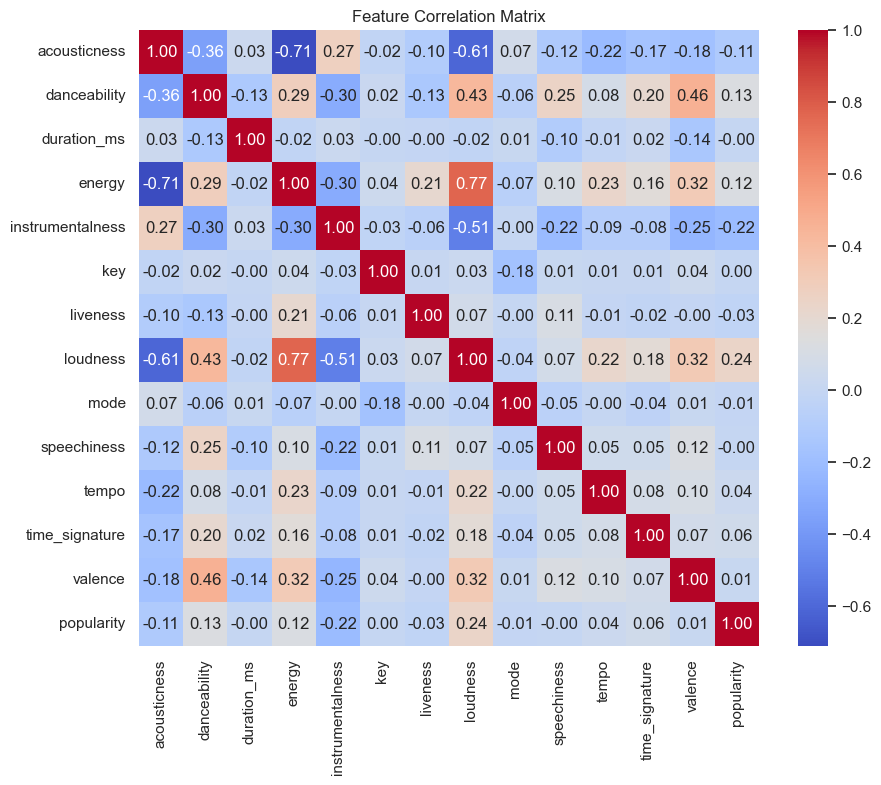

In [5]:
# Heatmap of attribute correlations. Essentially showing which attributes routinely line up for mood profiling
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

Initial Feature Observations
From the data I interpret several key "personalities" that reside.
Acousticness: This is heavily skewed towards zero, which indicates that most of this dataset consists of studio produced tracks and not 
acoustic performances of songs.
Danceability: Shows a clean distribution around .6, suggesting most tracks are at least "moderately danceable". Should help with mood profiling.
Tempo: There is a multimodal distribution here, around 120 BPM. This number also happens to the average BPM reached in modern popular music.

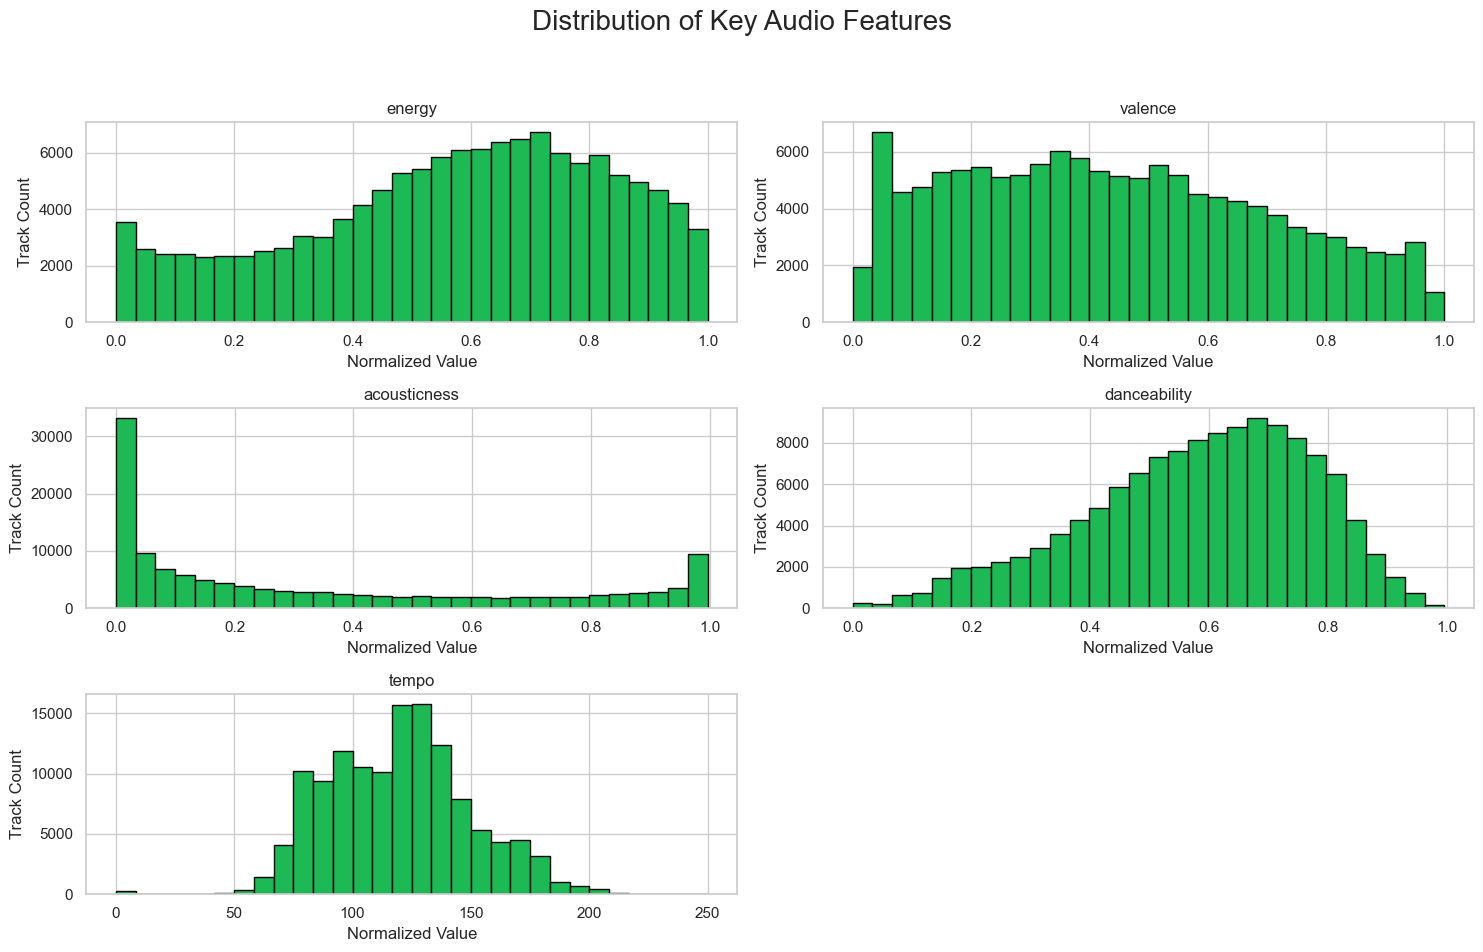

In [15]:
#Distribution analysis, specifically of mood features
features_to_plot = ['energy', 'valence', 'acousticness', 'danceability', 'tempo']
axes = df_clean[features_to_plot].hist(bins=30, figsize=(15, 10), color='#1db954', edgecolor='black')
plt.suptitle("Distribution of Key Audio Features", fontsize=20)

for ax in axes.flatten():
    ax.set_xlabel("Normalized Value")
    ax.set_ylabel("Track Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

To begin answering my first discovery question, tracks are being mapped here along two of the most emotionally significant axis,
that being Valence and Energy. Psychology of Music Theory dictates four quadrants of mood from music:
High Valence/High Energy: happy, excited, joyful.
Low Valence/High Energy: angry, tense, distorted.
Low Valence/Low Energy: sad, somber, depressed.
High Valence/Low Energy: calm, relaxed, serene.
This matters because it provides a baseline to compare K-Means clusters to down the line. It's possible atrtibues such as acousticness will pull
data in directions unforeseen.

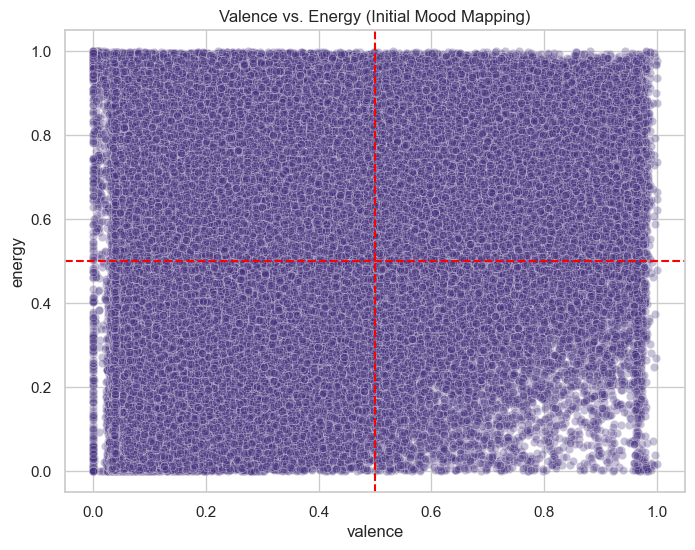

In [7]:
#Mood Map
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='valence', y='energy', alpha=0.3)
plt.axhline(0.5, color='red', linestyle='--')
plt.axvline(0.5, color='red', linestyle='--')
plt.title("Valence vs. Energy (Initial Mood Mapping)")
plt.show()

Three key immediate takeaways:
Instrumentalness is heavily skewed towards zero and that means the dataset is mostly vocal heavy tracks.
There is indeed a strong correlation between loudness and energy and that makes logial sense for studio recordings
In the scatter plot, valence/energy has a dense cloud in that high energy quadrant. Gives credence to there being a 'happy' mood cluster.

In [8]:
#Selecting features and scaling them to prepare for K means
from sklearn.preprocessing import StandardScaler
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
            'loudness', 'speechiness', 'tempo', 'valence']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])
df_scaled = pd.DataFrame(scaled_data, columns=features)
df_scaled.head()

,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence
0,-0.972716,0.850390,-0.885102,-0.622088,0.350641,2.386288,2.801903,-1.242716
1,-0.918937,1.392861,-0.047463,-0.622088,0.414685,2.772095,1.311269,-0.265741
2,-0.917201,0.113050,0.590372,-0.622088,0.623937,-0.536201,-0.150329,-0.223264
3,-0.904465,1.150592,0.037069,1.908648,-0.328011,-0.337671,0.116385,0.776880
4,-0.989460,1.061058,0.855496,1.814300,-0.046615,-0.369821,0.018288,1.885147


In order to visualize clusters, I am reducing track feature space using PCA. Principal Component Analysis squashes the data into two new axes, PC1 and PC2. These are designed to help capture as much variation information as possible from the original data set. This should help show data that otherwise would be invisible on a 2D chart. PC1 finds 40.3% and PC2 finds 14.8%, for a total of 55.1% variance. Capturing only 55% variance is a critical baseline and I want to avoid my 2D plot only being a simplified "shadow" of the data. Therefore, the  K-Means clustering will be done upon the full feature set and this ought to ensure that remaining 45% of data complexity is preserved for final results.

In [9]:
#Grabbing PCA for visualizations and reducing to two components so I can do 2D plots
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
#DF for PCA results
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
print(f"variance ratio is: {pca.explained_variance_ratio_}")

variance ratio is: [0.40323481 0.14813656]


To find distinct mood segmenets within the tracks, the elbow method is used to begin finding an optimal number of clusters (k) to map.
The goal in this chart is to find the "elbow" upon which there's a decrease in inertia and the plot slows down. The curve that is generated here is
fairly gradual in it's descent, but there is a visible inflection point at k=4. To be sure this isn't just a visual observation, the next step will be
to perform a mathematical Silhouette Analysis.

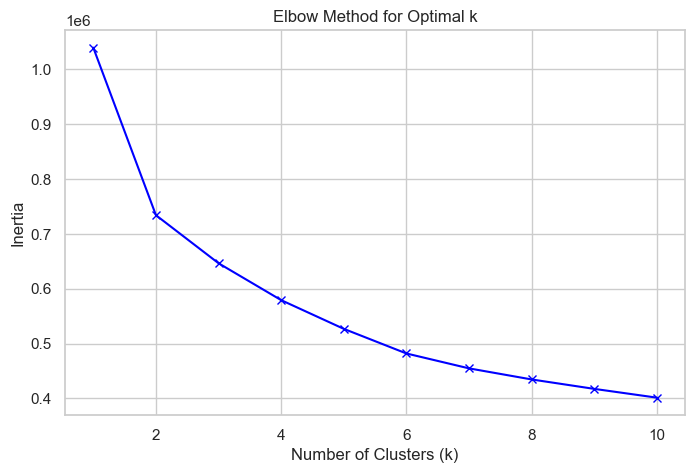

In [10]:
# Elbow Method to find optimal K
from sklearn.cluster import KMeans
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Silhouette Analysis is meant to measure track similarity within it's own cluster compared to other clusters. I'm testing k 2 - 5 to see if
the k = 4 decision is mathematically defensible.

In [11]:
# Validation/Testing k values to find the mathematical winner
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    test_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    test_labels = test_model.fit_predict(scaled_data) 
    score = silhouette_score(scaled_data, test_labels)
    print(f"For k={k}, the average silhouette_score is: {score:.3f}")

For k=2, the average silhouette_score is: 0.336
For k=3, the average silhouette_score is: 0.225
For k=4, the average silhouette_score is: 0.181
For k=5, the average silhouette_score is: 0.176


Upon reviewing the Silhouette scores, I've reached a justification for the model groupings. 
Firstly, I'd like to note that while k = 2 did reach the highest score, a model of k = 2 would not be befitting of this project as
that grouping would essentially boil down to (likely) Electronic vs Acoustic. This just doesn't provide enough granularity to answer my
initial discovery questions.
Observations: There is a sharp decline of -0.111 going from k = 2 to k = 3, indicating that data shapes are becoming less distinctive. The
drop from k = 4 to k = 5, however, is much smaller and tells me that k = 5 offers no real structural gain to the model. I decide upon k = 4 as the sweet spot for this model because it's Silhouette Score of 0.181 is balanced, nearly quartering the tracks. This should allow the model enough complexity to separate data into the distinct groupings mentioned previously of Party, Acoustic, Intense/Dark and Lyrical/Rhythmatic.

To validate whether or not K = 4 is robust, I perform here a density based analysis using DBSCAN. By tuning parameters to eps = 0.8 and min_samples = 50, the results I achieved contained minimal noise at only 16.69% percent. A few key take aways from the generated visualization: two primary, highly dense cores are identified, indicating a signifiant majority of Spotify data isn't random noise but rather has a consistent audio fingerprint. DB Scan, like the previous K-Means test, supports that there is a greater binary split in the data of k = 2. As noted previously, k = 4 will still be chosen in order to handle the granularity required of my discovery questions. This cross-validation does support that the four established profiles from this report are specialized segments of these larger and denser regions of musical data. That my groupings in this report are morses mathematical partitions than anything and that musical emotions exist on an overlapping gradiant most often.

DBSCAN estimated clusters: 2
Total noise points identified: 21687 (16.69% of data)


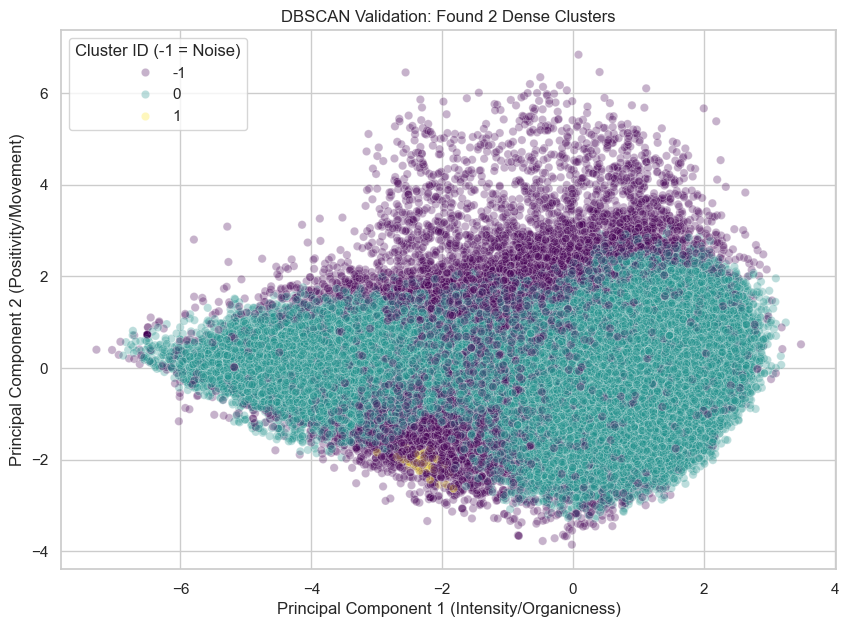

In [20]:
dbscan = DBSCAN(eps=0.8, min_samples=50) 
dbscan_labels = dbscan.fit_predict(scaled_data)

# Counting the clusters found (-1 indicates noise/outliers)
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"DBSCAN estimated clusters: {n_clusters_}")
print(f"Total noise points identified: {n_noise_} ({n_noise_/len(scaled_data):.2%} of data)")

# Visualization using the PCA components from Cell [9]
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=dbscan_labels, palette='viridis', alpha=0.3)
plt.title(f"DBSCAN Validation: Found {n_clusters_} Dense Clusters")
plt.xlabel("Principal Component 1 (Intensity/Organicness)")
plt.ylabel("Principal Component 2 (Positivity/Movement)")
plt.legend(title="Cluster ID (-1 = Noise)")
plt.show()

The Spotify Mood Profiles generated here address discovery question 3 by revealing that musical moods exist in a highly continuous density cloud. The visualization shows that while 'Acoustic' tracks are distinct, the center of the data space contains significant overlap between 'Dark' and 'Party' profiles, indicating a fluid emotional gradient. It does effectively show distinct groupings, with the yellow cluster (high energy/happy) being well separated from the blue cluster (acoustic). There is significant blurriness and overlap in the center of the plot. This is likely due to the missing 2D features that cannot be captured in a 2D space like tempo, key and mode. Therefore, while effectively outlining some broad trends, this is an incomplete map. My discovery here verifies that unsupervised learning from K-Means will be necessary to most effectively see results. This will be implemented/solved with a decision tree.

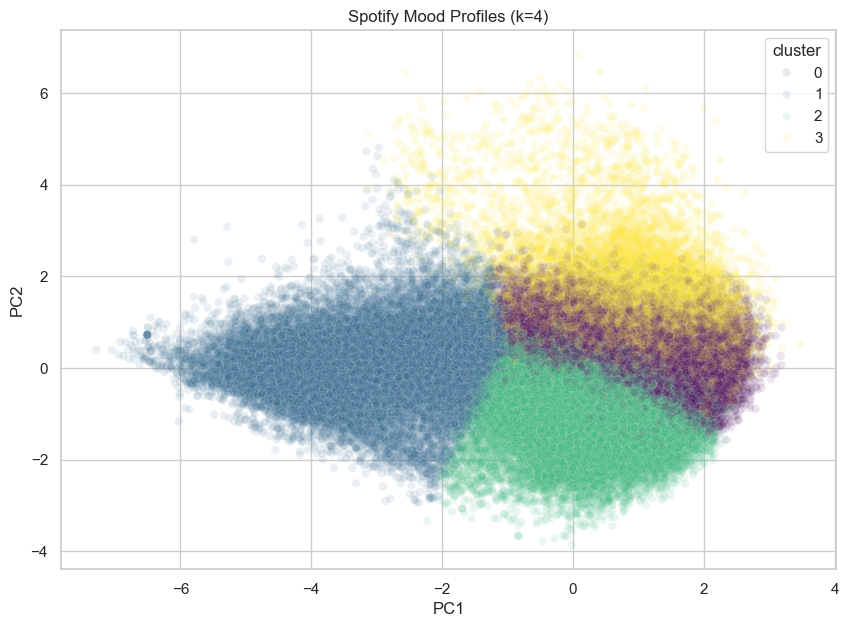

In [12]:
# Found optimal K, so K means implementation
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)
# add clusters
df_clean['cluster'] = clusters
df_pca['cluster'] = clusters
# Visualize the clusters with psa components
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.1)
plt.title(f"Spotify Mood Profiles (k={optimal_k})")
plt.show()

By grouping all 130,000 tracks and performing calcuulations to find mean feature values within each cluster, the second discovery question of ""Which features are the primary drivers of song similarity?" can be answered. Observations: Acousticness vs Energy are clearly the heavy hitters of the data. Cluster 1 has an acousticness of 0.84 while all other clusters are below 0.26. This determines that whether a song is plugged in/electronic in nature or acoustic is the most important factor in how Spotify's data is organized. Another significant finding is that while cluster 0 and 2 have nearly identical energy (0.67), they have a massive gap in their valence (0.68 vs 0.28). This is indicative of Emotional Tone (Valence) being the secondary driver in high energy music that distinguishes itself into "Happy/Party" or "Dark/Intense" categories.

In [13]:
# Cluster summary/defining mood groupings
cluster_summary = df_clean.groupby('cluster')[features].mean()
display(cluster_summary)

,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence
cluster,,,,,,,,
0,0.251044,0.700550,0.674893,0.112614,-7.056392,0.078294,118.546291,0.683075
1,0.841792,0.385971,0.204205,0.559573,-19.444770,0.054109,104.613152,0.255341
2,0.157972,0.535730,0.675122,0.209004,-7.515977,0.069516,128.586904,0.285299
3,0.257998,0.688458,0.606407,0.041674,-8.770810,0.361880,122.147158,0.494711


Based on the table above, four distinct groupings of Spotify's music has been mapped into clusters. Cluster 0 Happy/Party: Highest valence and danceability. These are the tracks that drive pop and club charts. Cluster 1 Purely Acoustic: Exceptionally high acousticness and lowest energy. This segment captures the organic sounding side of the dataset. Cluster 2 Intense/Dark: High energy and loudness paired with low valence. These tracks are rhythmically driving but emotionally heavy or aggressive. Cluster 3 Lyrical/Rhythmic: This highlights the importance of vocal delivery and rhythm over pure melodic presence in the track. 

To get past the blurriness that occurred on the previous PCA visualization, I've implemented a decision tree that acts as a sort of discovery tool. As opposed to PCA, which reduces data, this tree will view all features with their original dimensions to create exact, logical branches between music segments. This gives a hiearchy of musical attributes that distinguish mood profiles. The first key discovery from the tree is, surprisingly, that Valence is the primary root split, followed by energy and Speechiness. Initially I thought the primary branch would be acousticness, but valence happens to be more of a bridge to the acoustic cluster as low valence (<0.33) almost exclusively leads to it. There's a Sad/Deep split that occurs if a song is < 0.47 valence where it then looks at Energy. Higher energy leads to the Dark cluster, indicating that Dark music is moreso defined by intensity than emotional positivity. Also noteworthy is the "Vibe" split where if a song is Happy (Valence > 0.47), the model looks at Speechiness. Low Speehiness then defines the Party cluster where valence is (< 0.24), showing a focus on danceability and rhythym. High Speechiness is, as expected, the absolute identifying trait of the Lyrical cluster.

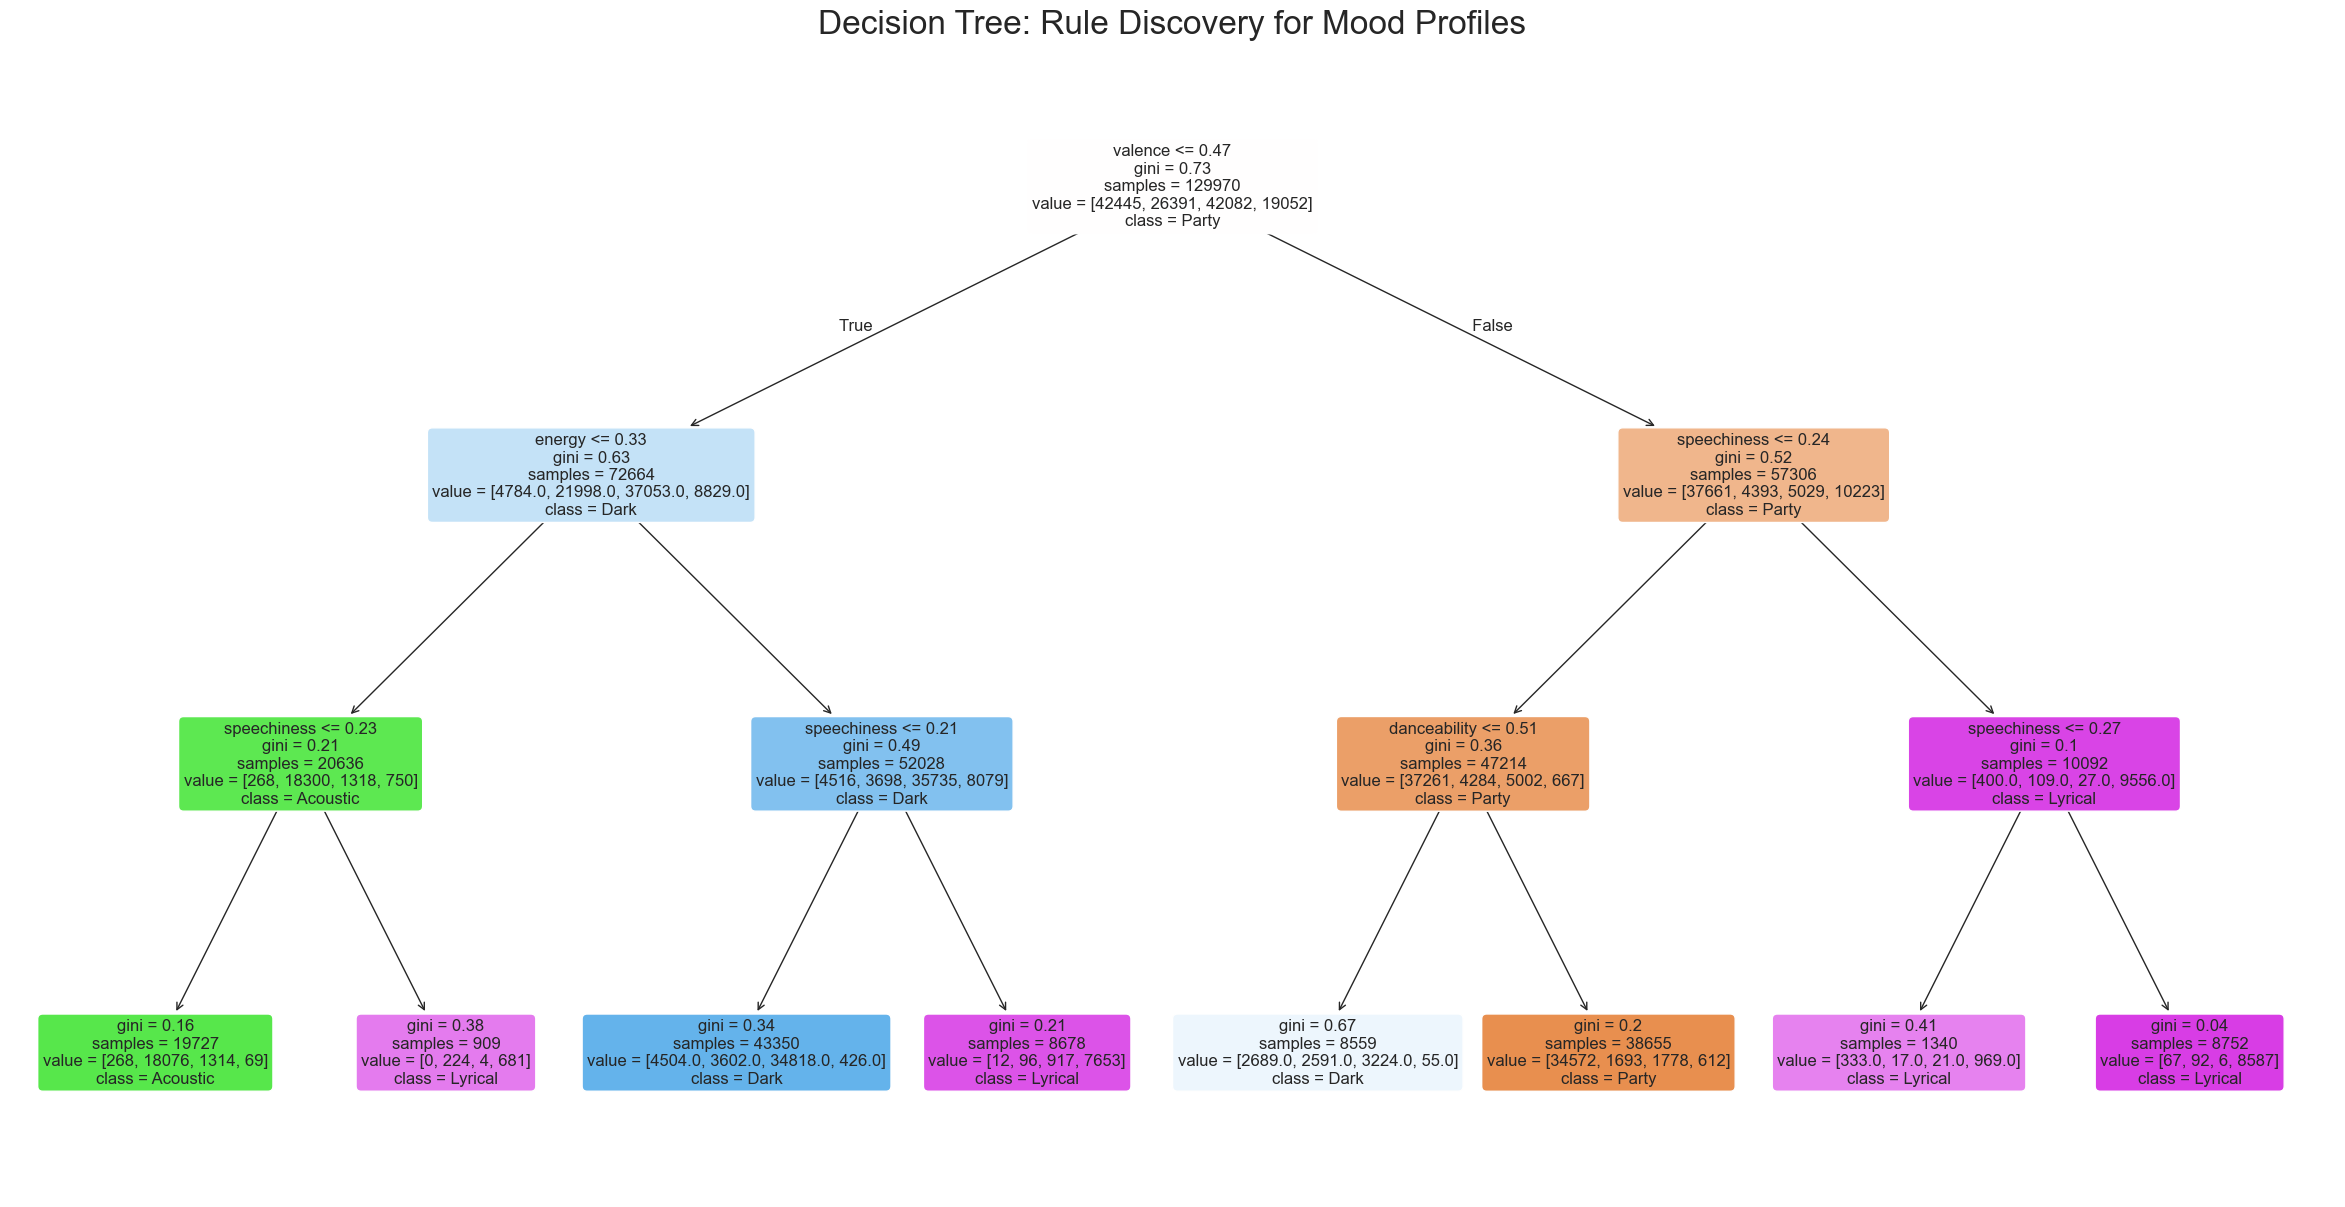

Decision Logic: 
|--- valence <= 0.47
|   |--- energy <= 0.33
|   |   |--- speechiness <= 0.23
|   |   |   |--- class: 1
|   |   |--- speechiness >  0.23
|   |   |   |--- class: 3
|   |--- energy >  0.33
|   |   |--- speechiness <= 0.21
|   |   |   |--- class: 2
|   |   |--- speechiness >  0.21
|   |   |   |--- class: 3
|--- valence >  0.47
|   |--- speechiness <= 0.24
|   |   |--- danceability <= 0.51
|   |   |   |--- class: 2
|   |   |--- danceability >  0.51
|   |   |   |--- class: 0
|   |--- speechiness >  0.24
|   |   |--- speechiness <= 0.27
|   |   |   |--- class: 3
|   |   |--- speechiness >  0.27
|   |   |   |--- class: 3



In [16]:
plt.figure(figsize=(30, 15))
plot_tree(tree_clf, 
          feature_names=features, 
          class_names=['Party', 'Acoustic', 'Dark', 'Lyrical'], 
          filled=True, 
          fontsize=12, 
          rounded=True,
          precision=2)
plt.title("Decision Tree: Rule Discovery for Mood Profiles", fontsize=24)
plt.show()

# rules for the DT
print("Decision Logic: ")
tree_rules = export_text(tree_clf, feature_names=list(features))
print(tree_rules)

The decision tree proves that despite the visual overlap in a 2D projection, the tracks are mathematically separable based on Valence and Energy